In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append
X = torch.tensor(X)
Y = torch.tensor(Y)


emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [7]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [8]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [9]:
# 整数索引不能直接进网络，因为数字自带大小关系，不符合字符的离散属性；
# 嵌入表 C 就是一张对照表：给每一个字符分配一串小数向量，把类别变成连续数字；
C = torch.randn((27, 2)) # C is the "embedding table"
# 27 个字符压缩到 2 个维度上
C.shape

torch.Size([27, 2])

In [10]:
C[5] # embedding a single integer 5, 比底下的one-hot 的方式更高效


tensor([0.3943, 0.1809])

In [11]:
F.one_hot(torch.tensor(5), num_classes=27).float()

tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [12]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C
# 1x27 @ 27x2 -> 1x2

tensor([0.3943, 0.1809])

In [13]:
C[torch.tensor([5, 6, 7])] # embedding a list of integers

tensor([[ 0.3943,  0.1809],
        [-0.4727,  0.7342],
        [-0.6572,  0.1646]])

In [14]:
C[X]

tensor([[[-0.7867, -0.7711],
         [-0.7867, -0.7711],
         [-0.7867, -0.7711]],

        [[-0.7867, -0.7711],
         [-0.7867, -0.7711],
         [ 0.3943,  0.1809]],

        [[-0.7867, -0.7711],
         [ 0.3943,  0.1809],
         [-0.4303,  0.2625]],

        [[ 0.3943,  0.1809],
         [-0.4303,  0.2625],
         [-0.4303,  0.2625]],

        [[-0.4303,  0.2625],
         [-0.4303,  0.2625],
         [-0.5438, -1.0901]],

        [[-0.7867, -0.7711],
         [-0.7867, -0.7711],
         [-0.7867, -0.7711]],

        [[-0.7867, -0.7711],
         [-0.7867, -0.7711],
         [ 1.2111,  0.2414]],

        [[-0.7867, -0.7711],
         [ 1.2111,  0.2414],
         [ 2.6257,  0.2021]],

        [[ 1.2111,  0.2414],
         [ 2.6257,  0.2021],
         [-0.7931,  0.2157]],

        [[ 2.6257,  0.2021],
         [-0.7931,  0.2157],
         [ 1.0491,  0.7875]],

        [[-0.7931,  0.2157],
         [ 1.0491,  0.7875],
         [-0.7931,  0.2157]],

        [[ 1.0491,  0

In [15]:
C[X].shape

torch.Size([32, 3, 2])

In [16]:
X[13, 2]

tensor(1)

In [17]:
C[X][13, 2]

tensor([-0.5438, -1.0901])

In [18]:
C[1]

tensor([-0.5438, -1.0901])

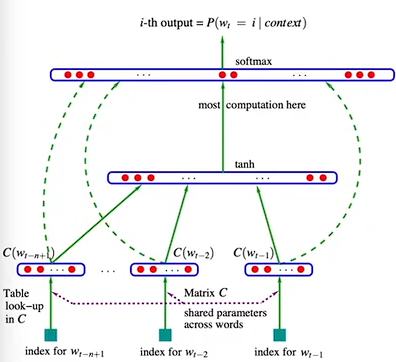

In [19]:
emb = C[X]

# hidden layer
W1 = torch.randn((6, 100))    # 6个输入(每个字符是2维向量，3个字符)，100个神经元
b1 = torch.randn(100)
# emb 是 32x3x2，需要先展平到 32x6，-1 表示自动计算第一个维度的大小（第二个维度指定了6）
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # 32x6 @ 6x100 -> 32x100
h.shape

torch.Size([32, 100])

In [20]:
h

tensor([[-0.4656,  0.9928,  0.0569,  ...,  0.9983,  0.9141, -0.9999],
        [-0.1958,  0.5934, -0.7496,  ...,  0.5692,  0.7247, -0.9015],
        [-0.2509,  0.9773, -0.4403,  ...,  0.8117, -0.6420, -0.9298],
        ...,
        [-0.6322,  0.0092,  0.1991,  ...,  0.9290,  0.9312,  0.6776],
        [-0.4347,  0.9389, -0.0661,  ...,  0.8875,  0.0868, -0.9750],
        [-0.2199,  0.6280,  0.5468,  ...,  0.9972,  0.8971, -0.9951]])

In [21]:
# output layer
W2 = torch.randn((100, 27))    # 100个输入，27个输出
b2 = torch.randn(27)
logits = h @ W2 + b2 # 32x100 @ 100x27 -> 32x27
count = logits.exp()
prob = count / count.sum(1, keepdims=True)


In [22]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(14.7743)

In [23]:
# ------ now made respectable ------

In [24]:
X.shape, Y.shape # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [25]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g) # C is the "embedding table"
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [26]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [27]:
emb = C[X] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)

# ======= F.cross_entropy(logits, Y) ======
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
loss = -prob[torch.arange(32), Y].log().mean()
loss


tensor(17.7697)

In [28]:
loss = F.cross_entropy(logits, Y)
# 交叉熵损失函数
loss


tensor(17.7697)

In [29]:
# ------ now made respectable :) ------

In [30]:
# build the dataset

def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [31]:
Xtr.shape, Ytr.shape, Xdev.shape, Ydev.shape, Xte.shape, Yte.shape

(torch.Size([182625, 3]),
 torch.Size([182625]),
 torch.Size([22655, 3]),
 torch.Size([22655]),
 torch.Size([22866, 3]),
 torch.Size([22866]))

In [32]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g) # C is the "embedding matrix"
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]


In [33]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [34]:
for p in parameters:
    p.requires_grad = True

In [35]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [36]:
lri = []
lossi = []
stepi = []

In [37]:
for i in range(200000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,)) 

    # forward pass
    emb = C[Xtr[ix]] 
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) 
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
    
# print(loss.item())

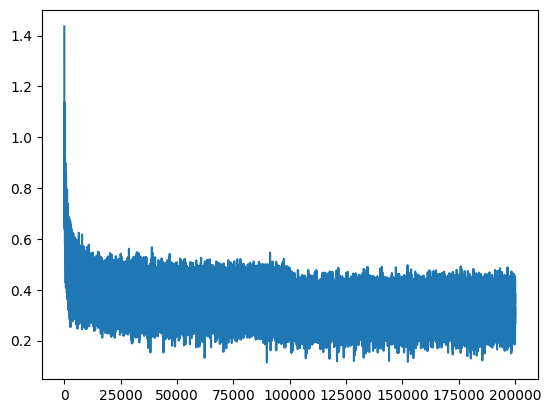

In [38]:
plt.plot(stepi, lossi)

In [39]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1182, grad_fn=<NllLossBackward0>)

In [40]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1511, grad_fn=<NllLossBackward0>)

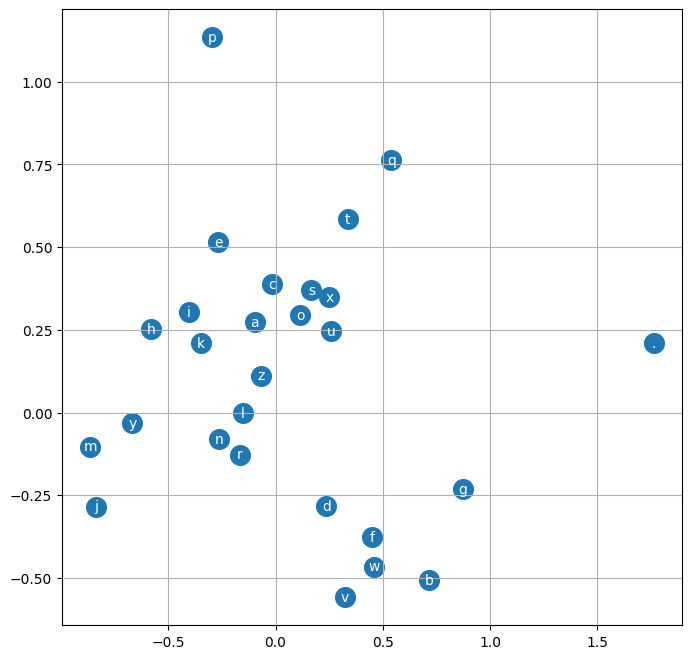

In [41]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

In [42]:
# training split, dev/validation split, test split
# 80%, 10%, 10%

In [43]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [44]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1) 
        logits = h @ W2 + b2 
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item() # sample
        context = context[1:] + [ix] # crop and append
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

mona.
amyah.
seel.
nihah.
lorethrettadrie.
caileed.
elin.
shi.
jenleigh.
edo.
aar.
elleigh.
kalin.
shuber.
dhiriel.
kindreelynn.
nophirous.
kaven.
jamyleyel.
yuma.
